<a href="https://colab.research.google.com/github/retutux-arch/Python_Data_Science_practica/blob/main/vamos_a_practicar_Pandas__conociendo_la_biblioteca_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***El equipo de ML ha llegado con algunas demandas de última hora que debemos resolver en este momento de análisis exploratorio. Estas demandas son las siguientes:***

In [2]:
import pandas as pd
url = 'https://gist.githubusercontent.com/ahcamachod/a572cfcc2527046db93101f88011b26e/raw/ffb13f45a79d31223e645611a119397dd127ee3c/alquiler.csv'
pd.read_csv(url, sep=';')

,Tipo,Colonia,Habitaciones,Garages,Suites,Area,Valor,Condominio,Impuesto
0,Cocineta,Condesa,1,0,0,40,5950.0,1750.0,210.0
1,Casa,Polanco,2,0,1,100,24500.0,NaN,NaN
2,Conjunto Comercial/Sala,Santa Fe,0,4,0,150,18200.0,14070.0,3888.5
3,Departamento,Centro Histórico,1,0,0,15,2800.0,1365.0,70.0
4,Departamento,Del Valle,1,0,0,48,2800.0,805.0,NaN
...,...,...,...,...,...,...,...,...,...
25116,Cochera/Estacionamiento,Centro Histórico,0,0,0,755,49000.0,NaN,NaN
25117,Cocineta,Centro Histórico,0,0,0,27,2800.0,1225.0,87.5
25118,Departamento,Mixcoac,2,1,0,48,4900.0,1781.5,129.5
25119,Departamento,Lomas de Chapultepec,2,0,0,70,10500.0,2660.0,NaN


1. **Calcular el promedio de habitaciones por departamento.**



In [40]:
datos = pd.read_csv(url, sep=';')
datos.query('Tipo == "Departamento"')



,Tipo,Colonia,Habitaciones,Garages,Suites,Area,Valor,Condominio,Impuesto
3,Departamento,Centro Histórico,1,0,0,15,2800.0,1365.0,70.0
4,Departamento,Del Valle,1,0,0,48,2800.0,805.0,NaN
7,Departamento,Centro Histórico,1,0,0,36,4200.0,NaN,NaN
8,Departamento,Condesa,1,0,1,40,7000.0,1963.5,175.0
10,Departamento,Condesa,4,3,1,243,45500.0,7000.0,2810.5
...,...,...,...,...,...,...,...,...,...
25111,Departamento,Lomas de Chapultepec,3,0,1,80,10500.0,3535.0,871.5
25113,Departamento,Coyoacán,3,1,2,150,52500.0,4900.0,2100.0
25114,Departamento,Narvarte,1,0,0,28,3500.0,1260.0,87.5
25118,Departamento,Mixcoac,2,1,0,48,4900.0,1781.5,129.5


In [41]:
df_departamentos = datos.query('Tipo == "Departamento"')
df_departamentos['Habitaciones'].mean()

np.float64(2.5041994039555675)

2. **Verificar cuántas colonias únicas existen en nuestra base de datos.**



In [62]:
datos['Colonia'].count()

np.int64(25121)

In [63]:
datos.Colonia.unique()
df_colonias_unicas = datos['Colonia'].unique()
print(f'El total de colonias unicas es de: {len(df_colonias_unicas)}')

El total de colonias unicas es de: 88


3. **Analizar qué colonias tienen el promedio de alquiler más alto.**

In [64]:
datos.groupby('Colonia')['Valor'].mean()

,Valor
Colonia,
Ajusco,20504.166667
Arboledas,6173.924731
Atlalilco,5705.000000
Atlampa,6607.500000
Barrio Bravo,36253.636364
...,...
Villa de Cortés,135737.411765
Villa de Guadalupe,14326.564189
Xochimilco,32025.000000


In [79]:
datos.groupby('Colonia')[['Valor']].mean().sort_values('Valor', ascending=False)

,Valor
Colonia,
San Juan Xalpa,420926.739130
Nativitas,244684.395062
La Merced,213292.770833
Santa Marta Acatitla,166048.105263
Villa de Cortés,135737.411765
...,...
Álvaro Obregón,3048.281250
San José Insurgentes,2660.000000
El Rodeo,2586.111111


In [73]:
df_5_max_alquiler = datos.groupby('Colonia')[['Valor']].mean().sort_values('Valor', ascending=False).head(5)


4. **Crear un gráfico de barras horizontales que muestre las 5 colonias con los promedios de alquiler más altos.**

<Axes: xlabel='Valor', ylabel='Colonia'>

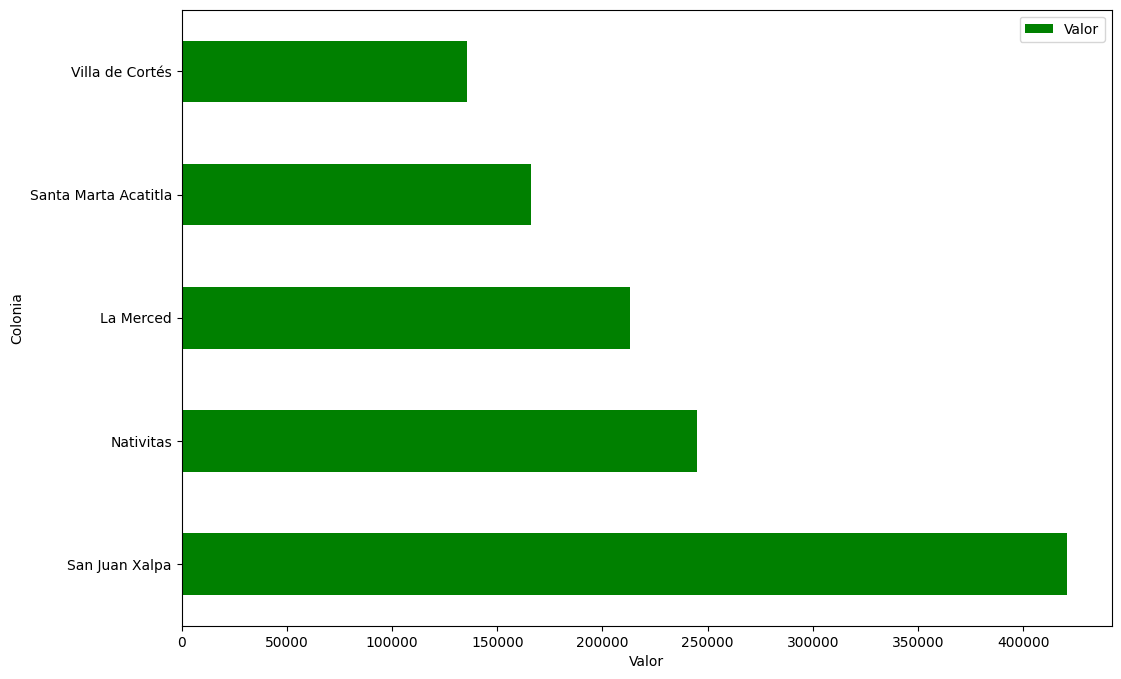

In [75]:
df_5_max_alquiler.plot(kind='barh', figsize=(12,8), color = 'green', xlabel='Valor',ylabel='Colonia')